# Visual features of Cartoon vs. Realistic Movie
This notebook performs analyses comparing visual features in otherwise content-matched movies. It contains supplemental analyses to the main notebook and must be separated because of different package requirements. See README.

**Table of Contents**
>[Set up](#setup)  
>[Complexity](#complexity)    
>[CNN outputs](#nn)  

## Set up <a id='setup'></a> 

Load packages and define some useful functions.

In [100]:
# Import functions 
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy as shannon_entropy
from scipy.stats import pearsonr
from scipy import stats
import glob
import os
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [101]:
# Get the base directory
curr_dir = os.getcwd()
os.chdir('../../') # Move into the infant neuropipe root
base_dir = os.getcwd() + '/'
os.chdir(curr_dir) # Come back

# set some paths that matter for this experiment 
save_plot_dir='%s/data/CartoonLive/plots/' %base_dir
rsa_dir = '%s/data/CartoonLive/vgg_outputs/' %base_dir
complexity_dir='%s/data/CartoonLive/complexity_outputs/' %base_dir
frame_dir='%s/data/CartoonLive/Frames/' %base_dir

# set the color palette
palette = ['#E9BC55','#E55924']

### Define functions 

In [102]:
# ---------- helpers ----------
def _orientation_entropy(ang, nbins=36):
    # ang in radians [-pi, pi] → [0, 2pi)
    ang = (ang + 2*np.pi) % (2*np.pi)
    hist, _ = np.histogram(ang, bins=nbins, range=(0, 2*np.pi))
    p = hist.astype(np.float64)
    s = p.sum()
    if s == 0: 
        return 0.0
    p /= s
    H = shannon_entropy(p, base=2)                 # bits
    return float(H / np.log2(nbins))               # normalize to [0,1]

def _direction_coherence(ang, tol_deg=20):
    # coherence = fraction of vectors within ±tol of circular mean direction
    if ang.size == 0:
        return 0.0
    ux = np.mean(np.cos(ang)); uy = np.mean(np.sin(ang))
    mean_ang = np.arctan2(uy, ux)
    d = np.abs(np.angle(np.exp(1j*(ang - mean_ang))))  # wrapped angular distance
    return float(np.mean(d <= np.deg2rad(tol_deg)))     # [0,1]

def _percentile_norm(x, p=95, eps=1e-8):
    x[~np.isfinite(x)]=np.nan # if there are inf values, turn them to nan 
    s = np.nanpercentile(x, p) + eps 
    return np.clip(x / s, 0, 1)

# ---------- per-frame measures ----------
def frame_shape_complexity(frame_bgr):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    # multi-scale Canny edge density
    med = np.median(gray)
    low  = int(max(0, 0.66*med)); high = int(min(255, 1.33*med))
    def edge_density(img):
        e = cv2.Canny(img, low, high)
        return float(np.count_nonzero(e)) / e.size

    g1 = gray
    g2 = cv2.GaussianBlur(gray, (0,0), 1.2)
    g3 = cv2.GaussianBlur(gray, (0,0), 2.4)
    edge_dens = np.mean([edge_density(g) for g in (g1,g2,g3)])  # ~[0,1]

    # orientation entropy (Sobel)
    gx = cv2.Sobel(g2, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g2, cv2.CV_32F, 0, 1, ksize=3)
    ang = np.arctan2(gy, gx)
    orient_H = _orientation_entropy(ang)                         # [0,1]

    # corner density (Shi–Tomasi)
    h, w = gray.shape
    corners = cv2.goodFeaturesToTrack(g2, maxCorners=2000, qualityLevel=0.01, minDistance=3)
    n_c = 0 if corners is None else corners.shape[0]
    # normalize roughly to [0,1] across HD-ish frames
    corner_dens = np.clip(n_c * 500.0 / (h*w), 0, 1)

    # combine (fixed weights; tune if you like)
    shape = 0.4*edge_dens + 0.4*orient_H + 0.2*corner_dens
    return shape, edge_dens, orient_H, corner_dens

def frame_color_complexity(frame_bgr, ab_bins=32):
    # OpenCV Lab: L in [0,255], a,b in [0,255]
    lab = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2LAB)
    L  = lab[...,0].astype(np.float32)
    a  = lab[...,1].astype(np.float32)
    b  = lab[...,2].astype(np.float32)

    L_std = float(L.std())                                   # luminance contrast (raw)
    H_ab, _, _ = np.histogram2d(a.ravel(), b.ravel(),
                                bins=ab_bins, range=[[0,255],[0,255]])
    p = H_ab.ravel().astype(np.float64)
    if p.sum() > 0: p /= p.sum()
    ab_H = float(shannon_entropy(p, base=2))                 # max = log2(bins^2)
    ab_H_norm = ab_H / np.log2(ab_bins*ab_bins)              # [0,1]

    # Final color score will normalize L_std across the video (percentile)
    return L_std, ab_H_norm

def frame_motion_complexity(prev_bgr, curr_bgr):
    if prev_bgr is None:
        return 0.0, 0.0, 0.0, 0.0
    pg = cv2.cvtColor(prev_bgr, cv2.COLOR_BGR2GRAY)
    cg = cv2.cvtColor(curr_bgr, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(pg, cg, None,
                                        pyr_scale=0.5, levels=3, winsize=15,
                                        iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
    mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
    mag_mean = float(np.mean(mag))                           # raw, to be normalized
    dir_H = _orientation_entropy(ang)                        # [0,1]
    coh   = _direction_coherence(ang)                        # [0,1]
    incoh = 1.0 - coh                                        # [0,1]
    # final motion will normalize mag_mean across the video
    return mag_mean, dir_H, incoh, coh

# ---------- pass 1: sample the video at 2 fps ----------
def sample_video_series(video_path, is_video =False, fps_sample=2):
    
    # split by whether you gave a video
    if is_video==True:
        print('Analyzing as a video')
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise FileNotFoundError(f"Cannot open {video_path}")

        fps = cap.get(cv2.CAP_PROP_FPS)
        nframes = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = nframes / fps if fps > 0 else 0.0
        times = np.arange(0.0, duration, 1.0/fps_sample)
        times = times[times*fps < nframes]
    
    # or a series of frames already 
    else:
        fps= 24 # HARD CODED 
        print('Analyzing as a folder of video frames (WARNING: assuming an fps of %d)' % (fps))
        all_frames = glob.glob(video_path+'*.png')
        all_frames = np.sort(all_frames) # sort by name (aka frame number)
        nframes=len(all_frames) # how many frames total
        times = np.arange(0.0, nframes, fps/fps_sample) # get a frame every X seconds
        times = times[times < nframes] # don't go over the time of the video 
        times=np.array(times,int) # integerize it 

    series = []
    prev_frame = None
    for t in times:
        idx = int(round(t*fps))
        
        # grab the video frame
        if is_video==True:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ok, frame = cap.read()
            if not ok:
                break
        # load the image
        else:
            # get the frame 
            frame = cv2.imread(all_frames[t])
            
            # then change the t value to an actual time in the video
            t = t*1/fps
            
        # shape & color on current frame
        shape, ed, oH, cD = frame_shape_complexity(frame)
        Lstd, abH = frame_color_complexity(frame)

        # motion from previous → current
        magMean, dirH, incoh, coh = frame_motion_complexity(prev_frame, frame)

        series.append({
            "time": float(t),
            "shape": shape, "shape_edge": ed, "shape_orientH": oH, "shape_cornerD": cD,
            "Lstd": Lstd, "abH": abH,
            "mag": magMean, "dirH": dirH, "incoh": incoh, "coh": coh,
            "frame": frame  # keep small reference for next step
        })
        prev_frame = frame

    if is_video==True:
        cap.release()
        
    # drop frames to free memory
    for r in series: r.pop("frame", None)
    return series

# ---------- pass 2: normalize color L* std and motion magnitude globally ----------
def normalize_and_combine(series):
    Lstd_arr = np.array([r["Lstd"] for r in series], dtype=np.float32)
    mag_arr  = np.array([r["mag"]  for r in series], dtype=np.float32)

    Lstd_n = _percentile_norm(Lstd_arr, 95)
    mag_n  = _percentile_norm(mag_arr, 95)

    out = []
    for i, r in enumerate(series):
        shape = r["shape"]                                              # already ~[0,1]
        color = 0.5*Lstd_n[i] + 0.5*r["abH"]                           # [0,1] approx
        motion = np.nansum([0.4*mag_n[i], 0.3*r["dirH"], 0.3*r["incoh"]]) # [0,1] approx

        overall = 0.4*shape + 0.3*color + 0.3*motion

        out.append({
            "time": r["time"],
            "overall": float(overall),
            "shape": float(shape),
            "color": float(color),
            "motion": float(motion),
            # diagnostics (optional)
            "Lstd_n": float(Lstd_n[i]), "abH": float(r["abH"]),
            "mag_n": float(mag_n[i]), "dirH": float(r["dirH"]), "incoh": float(r["incoh"])
        })
    return out

# ---------- aggregate to 90 × 2 s epochs ----------
def aggregate_to_epochs(frame_series, epoch_len=2.0, expected=90):
    t = np.array([r["time"] for r in frame_series])
    comps = {k: np.array([r[k] for r in frame_series], dtype=np.float32)
             for k in ["overall","shape","color","motion"]}

    ep = {k: [] for k in comps}
    for i in range(expected):
        a, b = i*epoch_len, (i+1)*epoch_len
        m = (t >= a) & (t < b)
        
        if m.any():
            for k in comps: ep[k].append(float(np.nanmean(comps[k][m])))
        else:
            # fallback: nearest time sample
            center = (a+b)/2
            j = int(np.argmin(np.abs(t - center)))
            for k in comps: ep[k].append(float(comps[k][j]))
        
    for k in ep: ep[k] = np.array(ep[k], dtype=np.float32)

    # (90,3) as [shape, color, motion]
    comp_nTRx3 = np.stack([ep["shape"], ep["color"], ep["motion"]], axis=1).astype(np.float32)
    return ep["overall"], comp_nTRx3

# Additional functions relevant to the notebook 
def randomise_diff_2sample(data_1, data_2, resample_num=1000):        
    '''Bootstrap resampling independent samples. 
    Take N samples with replacement from each group separately, average within group and then subtract. 
    Do this X times and report the p value of the number of samples in the opposite direction 
    from the true effect'''
    
    # Resample the participants
    resample_diff = []
    for i in range(resample_num):
        
        # Determine what participants to use in the sample
        sub_idx_1 = np.random.randint(0, len(data_1), (1, len(data_1)))
        
        sub_idx_2 = np.random.randint(0, len(data_2), (1, len(data_2)))

        resample_diff += [np.nanmean(data_1[sub_idx_1]) - np.nanmean(data_2[sub_idx_2])]
    
    # calculate the 2 way p value
    p_val = (1 - ((np.sum(np.asarray(resample_diff) > 0)) / (resample_num))) * 2
    
    # If the value is greater than 1 then subtract 2
    if p_val > 1:
        p_val = 2 - p_val
    
    CIs =[np.percentile(resample_diff, 2.5), np.percentile(resample_diff, 97.5)]
    
    mean_diff = np.nanmean(data_1) - np.nanmean(data_2)
    
    # return the pval, mean diff, and CIs
    return p_val, mean_diff, CIs

def bootstrap_corr(x_data,y_data,nPerm=1000):
    '''Bootstrap resampling for the correlation between two variables'''
    
    corr_dist=[]
    
    # Occasionally may have NaNs so need to leave them out if true
    if sum(np.isnan(np.array(x_data))) > 0:
        print('X data contains %s NaNs' %(sum(np.isnan(np.array(x_data)))))
    if sum(np.isnan(np.array(y_data))) > 0:
        print('Y data contains %s NaNs' %(sum(np.isnan(np.array(y_data)))))       
    
    not_nan=np.where(~np.isnan(np.array(x_data))*~np.isnan(np.array(y_data)))[0]
    x_data=np.array(x_data)[not_nan]
    y_data=np.array(y_data)[not_nan]
    
    for perm in range(nPerm):
        sampidx=np.random.choice(np.arange(x_data.shape[0]),x_data.shape[0],replace=True)
        random_x=np.array(x_data)[sampidx]
        random_y=np.array(y_data)[sampidx]
        rval, pval=pearsonr(random_x,random_y)
        corr_dist.append(rval)
    
    # calculate 2 way pval
    if stats.pearsonr(x_data,y_data)[0] < 0:
        pval=np.sum(np.array(corr_dist)>=0)/nPerm*2
    else:
        pval=np.sum(np.array(corr_dist)<=0)/nPerm*2
        
    # If the value is greater than 1 then subtract 2
    if pval > 1:
        pval = 2 - pval
        
    CIs =[np.percentile(corr_dist, 2.5), np.percentile(corr_dist, 97.5)]
          
    return pval, CIs

# Plot RSA matrices for different CNN layers 
def plot_rsa(rsa_dir,movie,layers):
    
    # preset a figure 
    fig = plt.figure(figsize=(30,6))
    
    # cycle through the different layers
    for layer_counter, layer in enumerate(layers):

        # What file is it
        filename = '%s/%s_vgg_%s.npy' % (rsa_dir, movie, layer)
       
        # load if path exists 
        if os.path.exists(filename) == 1:
            # Load in the data
            rsa = np.load(filename)
            
            # plot the data
            plt.subplot(1, len(layers), layer_counter + 1)
            plt.imshow(rsa,cmap='magma',)
            plt.title(layer)
            plt.yticks(np.arange(0,100,20))
            plt.xticks(np.arange(0,100,20))
            plt.clim([-0.15, 1]) # NOTE: range is truncated to show dynamic range of values
            
    return fig    

# Get the second-order correlation of two correlation matrices, ignoring a certain amount of the diagonal 
def correlate_matrices(rsa_dir,matrix1='LionKing_Live_vgg_b1p',matrix2='LionKing_Live_vgg_b2p',
                       off_diag=5,plot=False,randomise=False):

    filename1 = '%s/%s.npy' % (rsa_dir, matrix1)
    filename2 = '%s/%s.npy' % (rsa_dir, matrix2)
        
    if os.path.exists(filename1) == 1 and os.path.exists(filename2)==1:
        
        # Load in the data
        rsa1 = np.load(filename1)
        rsa2 = np.load(filename2)   
        
        # check if the same size, adjust if needed
        if rsa1.shape[0]>rsa2.shape[0]:
            print('wrong size! reducing size of %s to that of %s (%d by %d)' %(matrix1,matrix2,rsa2.shape[0],rsa2.shape[1]))
            rsa1=rsa1[:rsa2.shape[0],:rsa2.shape[0]]
        elif rsa1.shape[0]<rsa2.shape[0]:
            print('wrong size! reducing size of %s to that of %s (%d by %d)' %(matrix2,matrix1,rsa1.shape[0],rsa1.shape[1]))
            rsa2=rsa2[:rsa1.shape[0],:rsa1.shape[0]]
    
        # get the upper triangle
        upper_tri1=rsa1[np.triu_indices_from(rsa1,k=off_diag)] # exclude diagonal and first few diagonals
        upper_tri2=rsa2[np.triu_indices_from(rsa2,k=off_diag)] # exclude diagonal and first few diagonals
        
        # if randomise, shift the timing of one of them 
        if randomise==True:
            upper_tri2=np.roll(upper_tri2, shift=np.random.randint(0, len(upper_tri2) - 1))
        
        # correlate and get the slope
        r,pval=stats.pearsonr(upper_tri1,upper_tri2)
        slope,intercept,_,_,_=stats.linregress(upper_tri1,upper_tri2)
        
        print('corr=%0.3f; slope=%0.3f' % (r,slope))
        
        # plot if you want to plot 
        if plot==True:
            fig, ax = plt.subplots()
            plt.title('corr=%0.3f; slope=%0.3f' % (r,slope))
            plt.scatter(upper_tri1,upper_tri2,alpha=0.4)
            plt.xlabel(matrix1)
            plt.ylabel(matrix2)
            x_low, x_high, y_low, y_high = ax.axis() #Get axis limits
            plt.plot([min(x_low, y_low),max(x_high, y_high)],[min(x_low, y_low),max(x_high, y_high)],
                    linestyle='--',color='black') # plot the identity line 
            

    return r, slope

## Complexity <a id='complexity'></a> 
Analyze movies based on their visual complexity

In [93]:
# Run the analyses! 

# some parameters
fps_sample=2 # sampling of the frames
TR_len=2 # aggregation in seconds (2s TR) 
num_TRs=90 # expected number of TRs for the length of the movie 

# preset
overall_dict=dict()
comp_3_dict=dict()

# cycle through movies
for movie in ['LionKing_Live','LionKing_Cartoon']:
    
    # which movie
    print(movie)
    
    # where is the path 
    video_path = '%s/%s/' % (frame_dir,movie)
    
    # first, get the color, shape, and motion metrics at a given sampling rate 
    print("Sampling at %s fps…" % fps_sample)
    series = sample_video_series(video_path, fps_sample=fps_sample)
    print(f"Frames sampled: {len(series)}")

    # then, normalize color and motion value magnitude across the movie
    series = normalize_and_combine(series)

    # finally, aggregate values at the TR level
    print("Aggregating to 2s epochs…")
    overall, comp_3 = aggregate_to_epochs(series, epoch_len=TR_len, expected=num_TRs)

    # report the min, max, and mean
    print("Shape component (min, max, mean):",
          comp_3[:,0].min(), comp_3[:,0].max(), comp_3[:,0].mean())
    print("Color component   (min, max, mean):",
          comp_3[:,1].min(), comp_3[:,1].max(), comp_3[:,1].mean())
    print("Motion component  (min, max, mean):",
          comp_3[:,2].min(), comp_3[:,2].max(), comp_3[:,2].mean())

    # Save these values out 
    np.save("%s/%s_complexity_epochs_overall.npy" %(complexity_dir,movie), overall) # aggregated across measures
    np.save("%s/%s_complexity_epochs_comp_3.npy"   %(complexity_dir,movie), comp_3) # separated by complexity measure
    
    overall_dict[movie]=overall
    comp_3_dict[movie]=comp_3
    
    print()

LionKing_Live
Sampling at 2 fps…
Analyzing as a folder of video frames (WARNING: assuming an fps of 24)
Frames sampled: 376
Aggregating to 2s epochs…
Shape component (min, max, mean): 0.36008894 0.63296354 0.52180344
Color component   (min, max, mean): 0.24694484 0.70683736 0.4966823
Motion component  (min, max, mean): 0.25878716 0.9477308 0.6677604

LionKing_Cartoon
Sampling at 2 fps…
Analyzing as a folder of video frames (WARNING: assuming an fps of 24)
Frames sampled: 376
Aggregating to 2s epochs…
Shape component (min, max, mean): 0.13710201 0.5723317 0.38786596
Color component   (min, max, mean): 0.16375141 0.71050054 0.5465191
Motion component  (min, max, mean): 0.39414263 0.9307621 0.691166



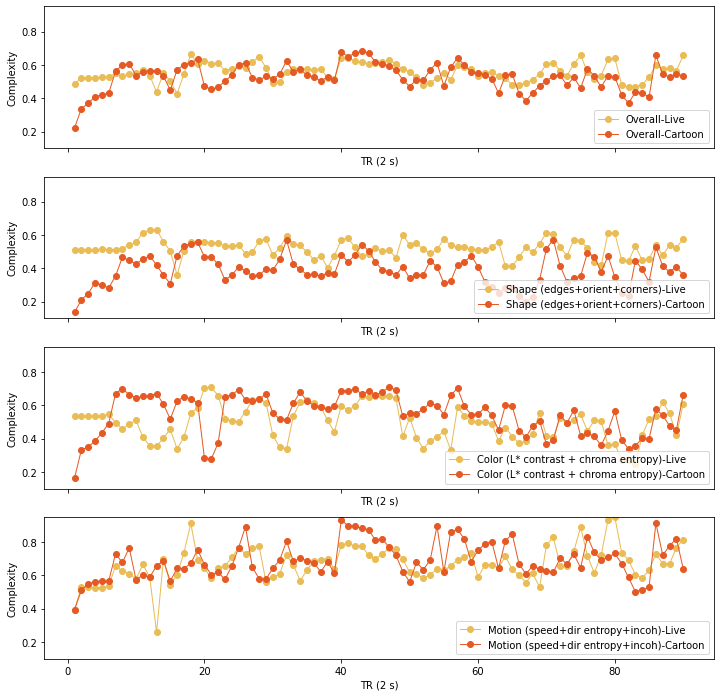

In [95]:
# Plot the complexity values across the two movies 
num_vals=4 # how many values are we plotting? (overall + 3 separate metrics )

# preset the subplots 
fig, ax = plt.subplots(num_vals,1,figsize=(12,12),sharex=True,sharey=True)
plt.ylim(0.1,0.95)

# cycle through the movies
for m, movie in enumerate(['LionKing_Live','LionKing_Cartoon']):
    
    epochs = np.arange(1, len(overall_dict[movie])+1) # how many epochs are there? 

    # overall
    ax[0].plot(epochs, overall_dict[movie], marker='o', linewidth=1, 
               label='Overall-%s' % movie.split('LionKing_')[-1],color=palette[m])
    
    # shape
    ax[1].plot(epochs, comp_3_dict[movie][:,0], marker='o', linewidth=1, 
               label='Shape (edges+orient+corners)-%s' % movie.split('LionKing_')[-1],color=palette[m])
    # color
    ax[2].plot(epochs, comp_3_dict[movie][:,1], marker='o', linewidth=1, 
               label='Color (L* contrast + chroma entropy)-%s' % movie.split('LionKing_')[-1],color=palette[m])
    # motion
    ax[3].plot(epochs, comp_3_dict[movie][:,2], marker='o', linewidth=1, 
               label='Motion (speed+dir entropy+incoh)-%s' % movie.split('LionKing_')[-1],color=palette[m])

# add some plotting things 
for idx in range(num_vals):
    ax[idx].set_ylabel("Complexity")
    ax[idx].set_xlabel("TR (2 s)")
    ax[idx].legend(loc='lower right')
    
plt.show()

fig.savefig(save_plot_dir+'complexity_cartoon_and_live.svg')

In [96]:
# Cycle through the components and report the mean, SD and difference between the two movies
for component,idx in zip(['Shape','Color','Motion'],range(comp_3.shape[1])):
    
    print(component)
    print('Cartoon: Mean=%0.3f, SD=%0.3f' %(np.nanmean(comp_3_dict['LionKing_Cartoon'][:,idx]),
      np.nanstd(comp_3_dict['LionKing_Cartoon'][:,idx])))
    print('Live: Mean=%0.3f, SD=%0.3f'%(np.nanmean(comp_3_dict['LionKing_Live'][:,idx]),
      np.nanstd(comp_3_dict['LionKing_Live'][:,idx])))

    np.random.seed(0)
    pval,mean_diff,CIs=randomise_diff_2sample(comp_3_dict['LionKing_Live'][:,idx],
                                           comp_3_dict['LionKing_Cartoon'][:,idx])
    print('Difference in complexity: %0.3f [%0.3f to %0.3f], pval=%0.3f' %(mean_diff,CIs[0],CIs[1],pval))
    
    print()
    

Shape
Cartoon: Mean=0.388, SD=0.089
Live: Mean=0.522, SD=0.052
Difference in complexity: 0.134 [0.113 to 0.155], pval=0.000

Color
Cartoon: Mean=0.547, SD=0.120
Live: Mean=0.497, SD=0.105
Difference in complexity: -0.050 [-0.083 to -0.016], pval=0.000

Motion
Cartoon: Mean=0.691, SD=0.109
Live: Mean=0.668, SD=0.104
Difference in complexity: -0.023 [-0.055 to 0.006], pval=0.120



Len of sub-epoch: 25
Cartoon color complexity (65 to 90 TRs): Mean=0.457, SD=0.081
Live color complexity (65 to 90 TRs): Mean=0.451, SD=0.100
Difference in color complexity: -0.006 [-0.058 to 0.045], pval=0.896


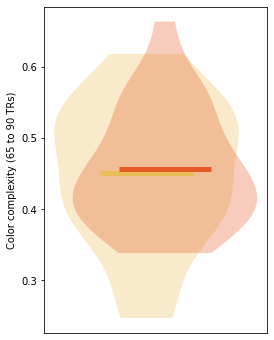

In [97]:
# Look at color complexity at the end of the movie, when it is seemingly matched
start_idx=65 # when to start 
stop_idx=90 # when to stop 

print('Len of sub-epoch:',stop_idx-start_idx)
fig = plt.figure(figsize=(4,6))

# plot the mean and distribution of color values in this epoch 
v = plt.violinplot([comp_3_dict['LionKing_Live'][start_idx:stop_idx,1],comp_3_dict['LionKing_Cartoon'][start_idx:stop_idx,1]],
               positions=[0,0.05],showextrema=False,showmeans=True,)
for pc, color in zip(v['bodies'], palette):
    pc.set_facecolor(color)
v['cmeans'].set_edgecolors(palette)
v['cmeans'].set_linewidth(5)
plt.xticks([])
plt.ylabel('Color complexity (%d to %d TRs)' %(start_idx,stop_idx))

fig.savefig(save_plot_dir+'color_complexity_violin_%dto%d.svg' % (start_idx,stop_idx))

print('Cartoon color complexity (%d to %d TRs): Mean=%0.3f, SD=%0.3f' %(start_idx,stop_idx,np.nanmean(comp_3_dict['LionKing_Cartoon'][start_idx:stop_idx,1]),
      np.nanstd(comp_3_dict['LionKing_Cartoon'][start_idx:stop_idx,1])))
print('Live color complexity (%d to %d TRs): Mean=%0.3f, SD=%0.3f'%(start_idx,stop_idx,np.nanmean(comp_3_dict['LionKing_Live'][start_idx:stop_idx,1]),
      np.nanstd(comp_3_dict['LionKing_Live'][start_idx:stop_idx,1])))

# Now get the statistical difference 
np.random.seed(0)
pval,mean_diff,CIs=randomise_diff_2sample(comp_3_dict['LionKing_Live'][start_idx:stop_idx,1],
                                           comp_3_dict['LionKing_Cartoon'][start_idx:stop_idx,1])

print('Difference in color complexity: %0.3f [%0.3f to %0.3f], pval=%0.3f' %(mean_diff,CIs[0],CIs[1],pval))

## CNN outputs <a id='cnn'></a> 
Analyze movies based on their representations in a convolutional neural network (VGG-19)

These files were created by running the script `run_generate_VGG_weights.sh` on the command line, which requires a conda environment that includes Keras and TensorFlow. The output files (frame x unit layer) were then transformed into TR x TR correlation matrices for ease of visualization using `run_analyse_VGG_weights.sh`. See code for details. 

In [110]:
# What are the layers of VGG you will look at? 
layers = ['b1p', 'b2p', 'b3p', 'b4p', 'b5p', 'fc1', 'fc2']

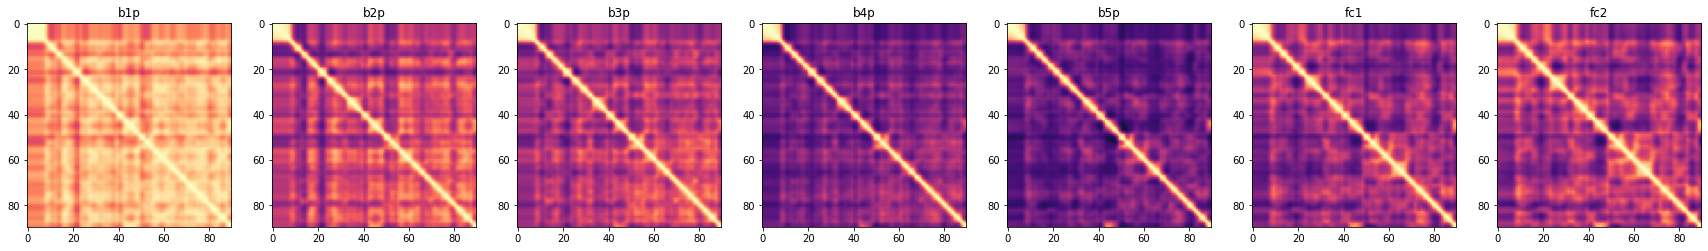

In [111]:
# Plot the TRxTR corr matrices for VGG layers for realistic movie 
fig = plot_rsa(rsa_dir,'LionKing_Live',layers)
fig.savefig(save_plot_dir+'live_vgg_reps.svg')

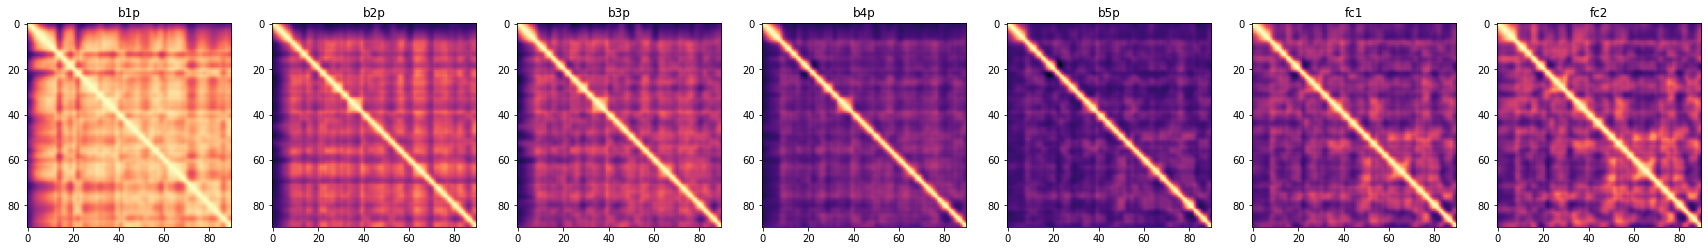

In [112]:
# Plot the TRxTR corr matrices for VGG layers for cartoon movie 
fig = plot_rsa(rsa_dir,'LionKing_Cartoon',layers)
fig.savefig(save_plot_dir+'cartoon_vgg_reps.svg')

corr=0.494; slope=0.269
corr=0.256; slope=0.234
corr=0.379; slope=0.362
corr=0.546; slope=0.614
corr=0.505; slope=0.683
corr=0.518; slope=0.603
corr=0.505; slope=0.534


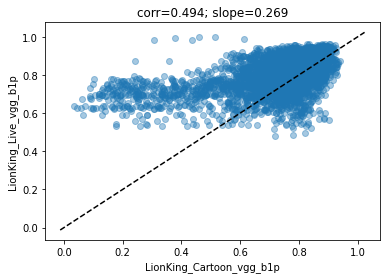

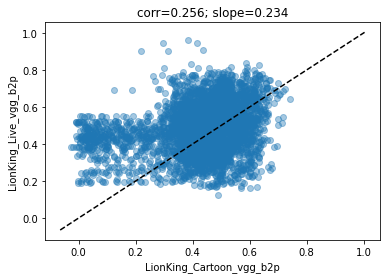

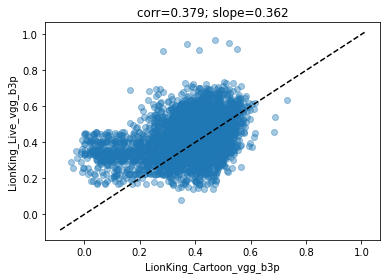

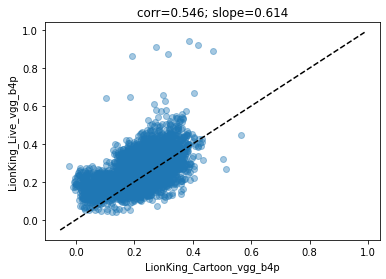

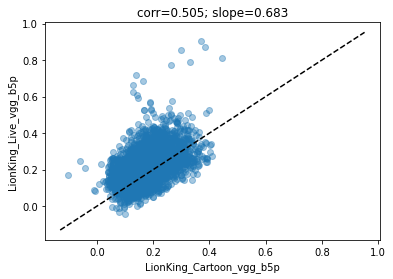

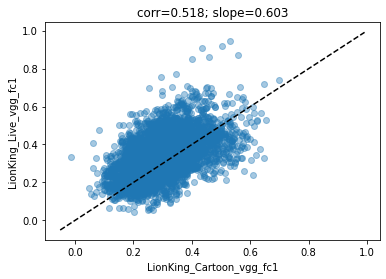

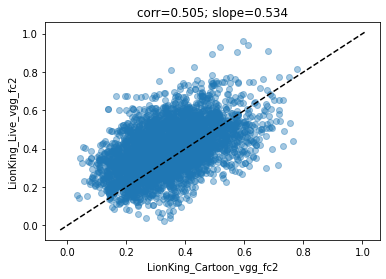

In [113]:
# Now, correlate the upper triangles of these two matrices

# preset
correlations=[]
slopes=[]

# cycle through layers
for layer in layers:
    
    # correlate Cartoon and Live 
    corr, slope=correlate_matrices(rsa_dir,matrix1='LionKing_Cartoon_vgg_%s' % layer,
                       matrix2='LionKing_Live_vgg_%s' % layer,off_diag=5,plot=True)
    
    # append the values
    correlations.append(np.square(corr)) # r-squared
    slopes.append(slope) # slope 

wrong size! reducing size of LionKing_Cartoon_vgg_b1p to that of Aeronaut_vgg_b1p (89 by 89)
corr=0.058; slope=0.114
wrong size! reducing size of LionKing_Cartoon_vgg_b2p to that of Aeronaut_vgg_b2p (89 by 89)
corr=0.130; slope=0.109
wrong size! reducing size of LionKing_Cartoon_vgg_b3p to that of Aeronaut_vgg_b3p (89 by 89)
corr=0.124; slope=0.138
wrong size! reducing size of LionKing_Cartoon_vgg_b4p to that of Aeronaut_vgg_b4p (89 by 89)
corr=0.189; slope=0.171
wrong size! reducing size of LionKing_Cartoon_vgg_b5p to that of Aeronaut_vgg_b5p (89 by 89)
corr=0.064; slope=0.094
wrong size! reducing size of LionKing_Cartoon_vgg_fc1 to that of Aeronaut_vgg_fc1 (89 by 89)
corr=0.105; slope=0.139
wrong size! reducing size of LionKing_Cartoon_vgg_fc2 to that of Aeronaut_vgg_fc2 (89 by 89)
corr=0.086; slope=0.115


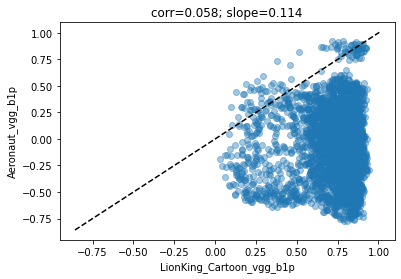

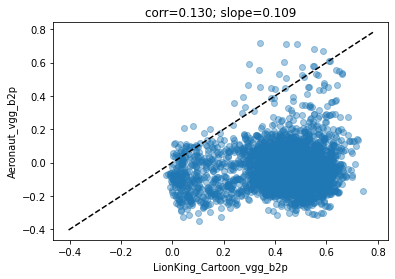

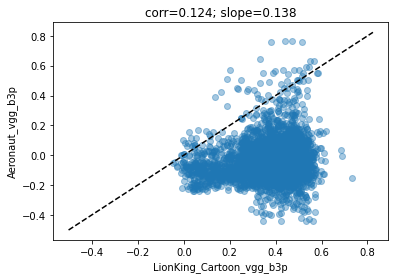

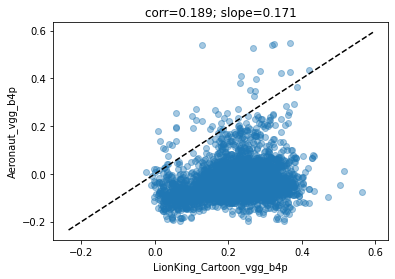

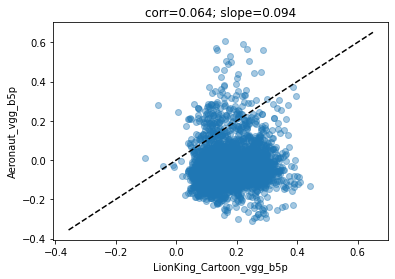

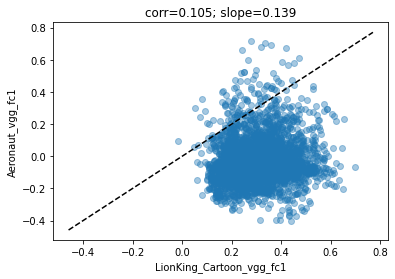

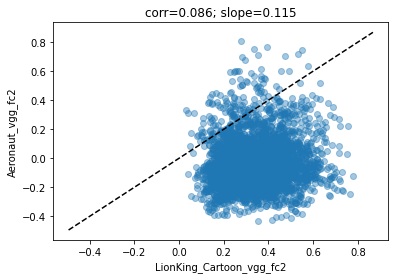

In [114]:
# Now, correlate the upper triangles with a CONTROL matrix -- namely, Aeronaut
# preset
correlations_random=[]
slopes_random=[]

# cycle through layers
for layer in layers:
    
    # correlate Cartoon and a different cartoon movie Aeronaut 
    corr, slope=correlate_matrices(rsa_dir,matrix1='LionKing_Cartoon_vgg_%s' % layer,
                       matrix2='Aeronaut_vgg_%s' % layer,off_diag=5,plot=True)
    
    # append 
    correlations_random.append(np.square(corr)) # r-squared
    slopes_random.append(slope) # slope

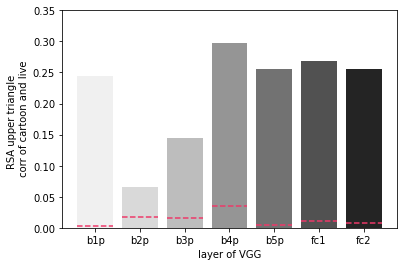

In [115]:
# Finally, create a figure that shows the correlation values across layers
# with the baseline random values as well
fig = plt.figure()
plt.bar(np.arange(len(layers)),correlations,color=sns.color_palette('Greys',len(layers)))
plt.xlabel('layer of VGG')
plt.ylabel('RSA upper triangle \n corr of cartoon and live')
_=plt.xticks(np.arange(len(layers)),layers)
plt.ylim(0,0.35)

# cycle through the layers 
for layer in np.arange(len(layers)):
    
    # plot the random values for comparison
    plt.plot([layer-0.4,layer+0.4],
             [correlations_random[layer],correlations_random[layer]],
             color='#EE3869',linestyle='dashed')

# save! 
fig.savefig(save_plot_dir+'rsa_validation_with_baseline_5offdiag.svg') # save (note the off-diagonal amount)